<a href="https://colab.research.google.com/github/anhhongdangcode-pixel/Database_Panic_Selling/blob/master/fomo_pipeline_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FOMO Detection — Data Pipeline & EDA
**Pipeline:** Raw CSV → Enriched Trades → Parquet → EDA

**Flow:**
1. Setup & Clone Repo
2. Data Pipeline (Loader + Builder)
3. Lưu `enriched_trades.parquet`
4. EDA — Khám phá mối quan hệ giữa features và `fomo_prob`

## 1. Setup & Clone Repo

In [1]:
# Clone repo về Colab — thay URL placeholder bằng link repo thật
!git clone https://github.com/anhhongdangcode-pixel/Python-for-data-analysis.git

# Cài thư viện cần thiết (Colab đã có pandas/numpy/matplotlib/seaborn/scipy)
!pip install pyarrow fastparquet --quiet   # để đọc/ghi Parquet

Cloning into 'Python-for-data-analysis'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 17 (delta 0), reused 5 (delta 0), pack-reused 12 (from 1)
Receiving objects: 100% (17/17), 51.74 MiB | 11.10 MiB/s, done.
Updating files: 100% (11/11), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 38.5 MB/s eta 0:00:00


## 2. Cấu hình đường dẫn

In [2]:
import os

# ── Đường dẫn gốc sau khi clone ───────────────────────────────────────────
REPO_DIR = "/content/Python-for-data-analysis"

INPUT_DIR  = os.path.join(REPO_DIR, "input")
OUTPUT_DIR = os.path.join(REPO_DIR, "output")

TRANSACTIONS_FILE  = os.path.join(INPUT_DIR, "transactions.csv")
CUSTOMERS_FILE     = os.path.join(INPUT_DIR, "customer_information.csv")
CLOSE_PRICES_FILE  = os.path.join(INPUT_DIR, "close_prices.csv")
ASSETS_FILE        = os.path.join(INPUT_DIR, "asset_information.csv")

SNORKEL_LABELS_FILE      = os.path.join(OUTPUT_DIR, "snorkel_labels.csv")
ENRICHED_TRADES_PARQUET  = os.path.join(OUTPUT_DIR, "enriched_trades.parquet")

print("Paths configured.")
print(f"  Input:  {INPUT_DIR}")
print(f"  Output: {OUTPUT_DIR}")

Paths configured.
  Input:  /content/Python-for-data-analysis/input
  Output: /content/Python-for-data-analysis/output


## 3. Imports

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

print("Imports OK.")

Imports OK.


## 4. Data Loader
Tích hợp từ `data_loader.py`.

**Thay đổi chính so với file gốc:**
- Bỏ hoàn toàn logic train/val split
- Chỉ giữ **Mass + Premium** (loại bỏ Professional, Legal Entity, Inactive)
- Output: **một DataFrame duy nhất** `enriched_trades`

In [4]:
# ── Encoding maps ─────────────────────────────────────────────────────────
_RISK_LEVEL_MAP = {
    "Conservative":           1.0,
    "Predicted_Conservative": 1.5,
    "Income":                 2.0,
    "Predicted_Income":       2.5,
    "Balanced":               3.0,
    "Predicted_Balanced":     3.5,
    "Aggressive":             4.0,
    "Predicted_Aggressive":   4.5,
    "Not_Available":          None,
}

_CAPACITY_ORDINAL_MAP = {
    "CAP_LT30K":             1, "Predicted_CAP_LT30K":     1,
    "CAP_30K_80K":           2, "Predicted_CAP_30K_80K":   2,
    "CAP_80K_300K":          3, "Predicted_CAP_80K_300K":  3,
    "CAP_GT300K":            4, "Predicted_CAP_GT300K":    4,
    "Not_Available":         None,
}

_CAPACITY_VALUE_MAP = {
    "CAP_LT30K":             15_000,  "Predicted_CAP_LT30K":    15_000,
    "CAP_30K_80K":           55_000,  "Predicted_CAP_30K_80K":  55_000,
    "CAP_80K_300K":          190_000, "Predicted_CAP_80K_300K": 190_000,
    "CAP_GT300K":            400_000, "Predicted_CAP_GT300K":   400_000,
    "Not_Available":         None,
}

PERIOD_START = "2020-07-01"
PERIOD_END   = "2022-11-30"


def _load_transactions(file: str) -> pd.DataFrame:
    transactions = pd.read_csv(file, parse_dates=["timestamp"])
    transactions["timestamp"] = pd.to_datetime(transactions["timestamp"])

    # Filter time period — bỏ COVID period và data artifact
    before = len(transactions)
    transactions = transactions[
        (transactions["timestamp"] >= PERIOD_START) &
        (transactions["timestamp"] <= PERIOD_END)
    ]
    print(f"[filter period] {before:,} → {len(transactions):,} rows "          f"({before - len(transactions):,} dropped)")

    # Data quality guard
    bad = (transactions["totalValue"] <= 0) | (transactions["units"] <= 0)
    if bad.sum() > 0:
        print(f"[WARNING] Dropping {bad.sum()} rows với totalValue/units <= 0")
        transactions = transactions[~bad]

    transactions["price"] = transactions["totalValue"] / transactions["units"]
    transactions["side"]  = transactions["transactionType"].str.upper()

    invalid = transactions[~transactions["side"].isin(["BUY", "SELL"])]
    if not invalid.empty:
        raise ValueError(f"Invalid transaction types: {invalid['side'].unique().tolist()}")

    trades = transactions[[
        "customerID", "ISIN", "timestamp", "side",
        "price", "units", "channel", "totalValue",
    ]].rename(columns={
        "customerID": "investor_id",
        "ISIN":       "asset_id",
        "units":      "quantity",
    })
    trades["investor_id"] = trades["investor_id"].astype(str)
    return trades


def _load_customers(file: str) -> pd.DataFrame:
    customers = pd.read_csv(file, parse_dates=["timestamp"])
    customers["timestamp"]  = pd.to_datetime(customers["timestamp"])
    customers["customerID"] = customers["customerID"].astype(str)

    # Dedup — lấy record mới nhất per customer
    customers = (
        customers
        .sort_values("timestamp")
        .drop_duplicates(subset=["customerID"], keep="last")
        .reset_index(drop=True)
    )
    assert customers["customerID"].nunique() == len(customers)

    customers["risk_level"]                  = customers["riskLevel"].map(_RISK_LEVEL_MAP)
    customers["investment_capacity_ordinal"] = customers["investmentCapacity"].map(_CAPACITY_ORDINAL_MAP)
    customers["investment_capacity_value"]   = customers["investmentCapacity"].map(_CAPACITY_VALUE_MAP)

    return customers[[
        "customerID", "customerType",
        "risk_level", "investment_capacity_ordinal", "investment_capacity_value",
    ]]


def _filter_by_asset_type(trades: pd.DataFrame, assets_file: str) -> pd.DataFrame:
    assets = pd.read_csv(assets_file)
    assets = (assets.sort_values("timestamp").groupby("ISIN").last().reset_index())
    stock_isins = assets[assets["assetCategory"] == "Stock"]["ISIN"].unique()

    before = len(trades)
    trades = trades[trades["asset_id"].isin(stock_isins)]
    print(f"[filter stock] {before:,} → {len(trades):,} rows "          f"({before - len(trades):,} non-Stock dropped)")
    return trades


def _attach_customer_features(trades: pd.DataFrame, customers: pd.DataFrame) -> pd.DataFrame:
    """
    Chỉ giữ Mass + Premium. Loại bỏ Professional, Legal Entity, Inactive.
    Trả về 1 DataFrame duy nhất (không train/val split).
    """
    valid_customers = customers[customers["customerType"].isin(["Mass", "Premium"])]
    print(f"[customer filter] Giữ Mass+Premium: {len(valid_customers):,} customers "          f"(loại bỏ {len(customers) - len(valid_customers):,} Professional/LegalEntity/Inactive)")

    customer_features = valid_customers[[
        "customerID", "risk_level",
        "investment_capacity_ordinal", "investment_capacity_value",
    ]].drop_duplicates(subset=["customerID"])

    result = trades[trades["investor_id"].isin(valid_customers["customerID"])]
    n_before = len(result)

    result = result.merge(
        customer_features,
        left_on="investor_id", right_on="customerID",
        how="left"
    ).drop(columns=["customerID"])

    assert len(result) == n_before,         f"[BUG] Join inflated trades! {n_before} → {len(result)} rows"

    # position_size_ratio = đo mức độ bet so với capacity
    result["position_size_ratio"] = result["totalValue"] / result["investment_capacity_value"]
    result = result.drop(columns=["investment_capacity_value"])

    print(f"[attach features] {len(result):,} trades | "          f"{result['investor_id'].nunique():,} investors")
    return result


def load_trade_data(transactions_file, customers_file, assets_file) -> pd.DataFrame:
    """
    Full pipeline: raw CSV → trades enriched với customer features.
    Output: 1 DataFrame duy nhất (Mass + Premium investors only).
    """
    trades    = _load_transactions(transactions_file)
    trades    = _filter_by_asset_type(trades, assets_file)
    customers = _load_customers(customers_file)
    trades    = _attach_customer_features(trades, customers)
    return trades


def load_close_prices(file: str, assets_file: str = None) -> pd.DataFrame:
    close_prices = pd.read_csv(file, parse_dates=["timestamp"])
    close_prices = close_prices.rename(columns={
        "ISIN": "asset_id", "closePrice": "market_price",
    })
    close_prices = close_prices[
        (close_prices["timestamp"] >= "2020-01-01") &
        (close_prices["timestamp"] <= PERIOD_END)
    ]
    if assets_file is not None:
        assets = pd.read_csv(assets_file)
        assets = assets.sort_values("timestamp").groupby("ISIN").last().reset_index()
        stock_isins = assets[assets["assetCategory"] == "Stock"]["ISIN"].unique()
        before = len(close_prices)
        close_prices = close_prices[close_prices["asset_id"].isin(stock_isins)]
        print(f"[close prices] filtered to Stock only: {before:,} → {len(close_prices):,} rows")

    return (close_prices[["asset_id", "timestamp", "market_price"]]
            .sort_values(["asset_id", "timestamp"])
            .reset_index(drop=True))

print("Data Loader functions defined.")

Data Loader functions defined.


## 5. Data Builder
Tích hợp từ `data_builder.py`.

Enriches market data với: business-day reindex, returns (1d/5d), volatility (5d/10d), MA (5/20), RSI-14, MACD histogram.

In [5]:
def build_trades(trades: pd.DataFrame) -> pd.DataFrame:
    trades = trades.copy()
    trades["timestamp"] = pd.to_datetime(trades["timestamp"])
    return trades.sort_values(["investor_id", "timestamp"]).reset_index(drop=True)


def _reindex_to_business_days(market: pd.DataFrame) -> pd.DataFrame:
    """
    Reindex về business days (Mon-Fri) và forward fill gap.
    Fix: pct_change(h) sau reindex đo đúng h trading days, không bị inflate bởi weekend gap.
    """
    start = market["timestamp"].min()
    end   = market["timestamp"].max()
    full_bday_idx = pd.date_range(start=start, end=end, freq="B")

    parts = []
    for asset_id, group in market.groupby("asset_id"):
        group = group.set_index("timestamp").reindex(full_bday_idx)
        group["asset_id"]    = asset_id
        group["market_price"] = group["market_price"].ffill()
        group.index.name = "timestamp"
        parts.append(group.reset_index())

    return (pd.concat(parts, ignore_index=True)
            .sort_values(["asset_id", "timestamp"])
            .reset_index(drop=True))


def _add_market_returns(market: pd.DataFrame, horizons=(1, 5)) -> pd.DataFrame:
    for h in horizons:
        market[f"return_{h}d"] = (
            market.groupby("asset_id")["market_price"].pct_change(h)
        )
    return market


def _add_market_volatilities(market: pd.DataFrame, windows=(5, 10)) -> pd.DataFrame:
    for w in windows:
        market[f"volatility_{w}d"] = (
            market.groupby("asset_id")["return_1d"]
            .rolling(w).std()
            .reset_index(level=0, drop=True)
        )
    return market


def _add_moving_averages(market: pd.DataFrame, windows=(5, 20)) -> pd.DataFrame:
    for w in windows:
        market[f"ma_{w}d"] = (
            market.groupby("asset_id")["market_price"]
            .transform(lambda x: x.rolling(w, min_periods=1).mean())
        )
    market["price_above_ma20"] = market["market_price"] / market["ma_20d"]
    return market


def _add_rsi(market: pd.DataFrame, period: int = 14) -> pd.DataFrame:
    def _compute_rsi(prices, period):
        delta    = prices.diff()
        gain     = delta.clip(lower=0)
        loss     = (-delta).clip(lower=0)
        avg_gain = gain.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
        avg_loss = loss.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
        rs  = avg_gain / avg_loss.replace(0, np.nan)
        return 100 - (100 / (1 + rs))

    market[f"rsi_{period}"] = (
        market.groupby("asset_id")["market_price"]
        .transform(lambda x: _compute_rsi(x, period))
    )
    return market


def _add_macd(market: pd.DataFrame, fast=12, slow=26, signal=9) -> pd.DataFrame:
    def _compute_macd(prices):
        ema_fast    = prices.ewm(span=fast, adjust=False).mean()
        ema_slow    = prices.ewm(span=slow, adjust=False).mean()
        macd_line   = ema_fast - ema_slow
        signal_line = macd_line.ewm(span=signal, adjust=False).mean()
        return macd_line - signal_line  # histogram

    market["macd_hist"] = (
        market.groupby("asset_id")["market_price"]
        .transform(_compute_macd)
    )
    return market


def build_market(market: pd.DataFrame) -> pd.DataFrame:
    required = {"asset_id", "timestamp", "market_price"}
    missing  = required - set(market.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    market = market.copy().sort_values(["asset_id", "timestamp"]).reset_index(drop=True)

    print("[build_market] Reindexing to business days...")
    market = _reindex_to_business_days(market)
    market = _add_market_returns(market)
    market = _add_market_volatilities(market)
    market = _add_moving_averages(market)
    market = _add_rsi(market)
    market = _add_macd(market)

    print(f"[build_market] Done. Shape: {market.shape}, "          f"Assets: {market['asset_id'].nunique()}, "          f"Date range: {market['timestamp'].min().date()} → {market['timestamp'].max().date()}")
    return market


def enrich_trades_with_market(trades: pd.DataFrame, market: pd.DataFrame) -> pd.DataFrame:
    market = market.drop_duplicates(subset=["asset_id", "timestamp"])
    enriched = trades.merge(market, on=["asset_id", "timestamp"], how="left")

    no_match = enriched["market_price"].isna().sum()
    if no_match > 0:
        pct = no_match / len(enriched) * 100
        print(f"[WARNING] {no_match:,} trades ({pct:.1f}%) không match được market data")
    return enriched

print("Data Builder functions defined.")

Data Builder functions defined.


## 6. Chạy Pipeline → `enriched_trades`
Load raw CSV → filter → enrich market context → tạo `enriched_trades` duy nhất.

In [7]:
print("=" * 60)
print("STEP 1: Load & filter trades (Mass + Premium, Stock only, Jul2020–Nov2022)")
print("=" * 60)

trades = load_trade_data(
    transactions_file=TRANSACTIONS_FILE,
    customers_file=CUSTOMERS_FILE,
    assets_file=ASSETS_FILE,
)
print(f"\nTrades shape: {trades.shape}")
print(f"Columns: {list(trades.columns)}")

print("\n" + "=" * 60)
print("STEP 2: Build enriched market data")
print("=" * 60)

raw_market = load_close_prices(file=CLOSE_PRICES_FILE, assets_file=ASSETS_FILE)
market     = build_market(raw_market)

print("\n" + "=" * 60)
print("STEP 3: Enrich trades với market context")
print("=" * 60)

trades = build_trades(trades)
enriched_trades = enrich_trades_with_market(trades, market)

# Thêm tx_id — dùng làm join key với snorkel_labels.csv
enriched_trades = enriched_trades.reset_index(drop=True)
enriched_trades.insert(0, "tx_id", enriched_trades.index)

print(f"\nFinal enriched_trades shape: {enriched_trades.shape}")
print(f"Columns: {list(enriched_trades.columns)}")
print(f"\nSample (3 rows):")
display(enriched_trades.head(3))

# NaN summary
nan_pct = enriched_trades.isnull().mean() * 100
nan_pct = nan_pct[nan_pct > 0].round(1)
if len(nan_pct):
    print(f"\nNaN % per column:")
    print(nan_pct.to_string())
    print("→ NaN ở return/MA/RSI đầu series là bình thường (warmup period)")
else:
    print("\n✓ Không có NaN")

STEP 1: Load & filter trades (Mass + Premium, Stock only, Jul2020–Nov2022)
[filter period] 388,048 → 239,666 rows (148,382 dropped)
[filter stock] 239,666 → 213,399 rows (26,267 non-Stock dropped)
[customer filter] Giữ Mass+Premium: 27,516 customers (loại bỏ 1,574 Professional/LegalEntity/Inactive)
[attach features] 199,932 trades | 13,474 investors

Trades shape: (199932, 11)
Columns: ['investor_id', 'asset_id', 'timestamp', 'side', 'price', 'quantity', 'channel', 'totalValue', 'risk_level', 'investment_capacity_ordinal', 'position_size_ratio']

STEP 2: Build enriched market data
[close prices] filtered to Stock only: 417,380 → 178,579 rows
[build_market] Reindexing to business days...


/tmp/ipykernel_6937/502618976.py:32: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  market.groupby("asset_id")["market_price"].pct_change(h)
/tmp/ipykernel_6937/502618976.py:32: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  market.groupby("asset_id")["market_price"].pct_change(h)


[build_market] Done. Shape: (193040, 12), Assets: 254, Date range: 2020-01-01 → 2022-11-29

STEP 3: Enrich trades với market context
[WARNING] 278 trades (0.1%) không match được market data

Final enriched_trades shape: (199932, 22)
Columns: ['tx_id', 'investor_id', 'asset_id', 'timestamp', 'side', 'price', 'quantity', 'channel', 'totalValue', 'risk_level', 'investment_capacity_ordinal', 'position_size_ratio', 'market_price', 'return_1d', 'return_5d', 'volatility_5d', 'volatility_10d', 'ma_5d', 'ma_20d', 'price_above_ma20', 'rsi_14', 'macd_hist']

Sample (3 rows):


,tx_id,investor_id,asset_id,timestamp,side,price,quantity,channel,totalValue,risk_level,...,market_price,return_1d,return_5d,volatility_5d,volatility_10d,ma_5d,ma_20d,price_above_ma20,rsi_14,macd_hist
0,0,0004718496C71D464F57,GRS191213008,2021-01-04,BUY,1.682,5000.0,Phone Banking,8410.0,1.5,...,1.682,-0.000297,0.019394,0.017784,0.018442,1.68890,1.623575,1.035985,57.073700,-0.002586
1,1,0004718496C71D464F57,GRS014003032,2021-01-07,BUY,19.904,312.5,Phone Banking,6220.0,1.5,...,19.904,-0.018056,-0.043077,0.017916,0.034596,20.05120,19.331760,1.029601,56.517850,-0.022799
2,2,0004718496C71D464F57,GRS003003035,2021-01-07,BUY,2.160,5000.0,Phone Banking,10800.0,1.5,...,2.160,-0.035284,-0.044670,0.031780,0.030985,2.21875,2.161917,0.999113,59.035919,-0.029359



NaN % per column:
risk_level                     0.2
investment_capacity_ordinal    0.2
position_size_ratio            0.2
market_price                   0.1
return_1d                      0.7
return_5d                      0.8
volatility_5d                  0.8
volatility_10d                 0.9
ma_5d                          0.1
ma_20d                         0.1
price_above_ma20               0.1
rsi_14                         1.0
macd_hist                      0.1
→ NaN ở return/MA/RSI đầu series là bình thường (warmup period)


## 7. Lưu `enriched_trades.parquet`
Parquet nhỏ hơn CSV ~4–5x và load nhanh hơn nhiều.
Các cell EDA sau đây load lại từ file này để tránh re-run toàn bộ pipeline.

In [9]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
enriched_trades.to_parquet(ENRICHED_TRADES_PARQUET, index=False)

size_mb = os.path.getsize(ENRICHED_TRADES_PARQUET) / 1024 / 1024
print(f"✓ Saved: {ENRICHED_TRADES_PARQUET}  ({size_mb:.1f} MB)")
print(f"  Rows: {len(enriched_trades):,}  |  Columns: {enriched_trades.shape[1]}")

✓ Saved: /content/Python-for-data-analysis/output/enriched_trades.parquet  (10.1 MB)
  Rows: 199,932  |  Columns: 22


---
## 8. EDA — FOMO Detection
**Mục tiêu:** Khám phá mối quan hệ giữa các features và `fomo_prob` để justify feature selection trước khi train XGBoost.

**Flow:**
1. Load data + palette setup
2. Overview: data types, missing values, fomo_prob distribution
3. Phần 1 — LF-related features: FIG 1 (distribution) & FIG 2 (RSI + value spike)
4. Phần 2 — Non-leakage features: FIG 3 (rejected) & FIG 4 (selected)

### 8.1 Load data & Palette setup

In [11]:
# ── Load enriched_trades từ Parquet ───────────────────────────────────────
enriched = pd.read_parquet(ENRICHED_TRADES_PARQUET)
print(f"enriched_trades: {enriched.shape}")

# ── Load snorkel_labels và join vào enriched ──────────────────────────────
snorkel = pd.read_csv(SNORKEL_LABELS_FILE)
print(f"snorkel_labels:  {snorkel.shape}")
print(f"snorkel columns: {snorkel.columns.tolist()}")

# Join theo tx_id
df = enriched.merge(snorkel[["tx_id", "fomo_prob", "lf_LF_rsi_extreme",
                              "lf_LF_value_spike", "lf_LF_trade_cluster",
                              "lf_LF_return_momentum", "lf_LF_bollinger_breakout"]],
                    on="tx_id", how="inner")
print(f"\nAfter join: {df.shape}")

# ── Palette thống nhất toàn EDA ───────────────────────────────────────────
C_FOMO   = '#E8622A'
C_NORMAL = '#3A86C8'
C_MID    = '#A8A8A8'
C_BG     = '#F7F7F7'
CMAP_DIV = 'RdBu_r'
CMAP_SEQ = 'OrRd'
PALETTE_Q = [C_NORMAL, '#7BB8E0', C_MID, C_FOMO]   # Q1 → Q4

def make_quartiles(series, labels):
    return pd.qcut(series.rank(method='first'), q=len(labels), labels=labels)

plt.rcParams.update({
    'figure.facecolor' : C_BG,
    'axes.facecolor'   : C_BG,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.color'       : '#DDDDDD',
    'grid.linewidth'   : 0.6,
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})
print("Setup done.")

enriched_trades: (199932, 22)
snorkel_labels:  (105467, 11)
snorkel columns: ['tx_id', 'investor_id', 'timestamp', 'fomo_prob', 'lf_votes', 'all_abstain', 'lf_LF_trade_cluster', 'lf_LF_return_momentum', 'lf_LF_rsi_extreme', 'lf_LF_bollinger_breakout', 'lf_LF_value_spike']

After join: (105467, 28)
Setup done.


### 8.2 Overview — Data types, missing values, fomo_prob summary

In [13]:
print('=== Data types & missing values ===')
summary = pd.DataFrame({
    'dtype'   : df.dtypes,
    'missing' : df.isna().sum(),
    'missing%': (df.isna().mean() * 100).round(2),
    'nunique' : df.nunique(),
})
display(summary)

print('\n=== fomo_prob distribution ===')
print(df['fomo_prob'].describe().round(4))

=== Data types & missing values ===


,dtype,missing,missing%,nunique
tx_id,int64,0,0.00,105467
investor_id,object,0,0.00,6132
asset_id,object,0,0.00,160
timestamp,datetime64[ns],0,0.00,605
side,object,0,0.00,1
price,float64,0,0.00,8750
quantity,float64,0,0.00,4362
channel,object,0,0.00,3
totalValue,float64,0,0.00,32788
risk_level,float64,114,0.11,8



=== fomo_prob distribution ===
count    105467.0000
mean          0.3680
std           0.3753
min           0.0705
25%           0.0705
50%           0.0834
75%           0.8373
max           1.0000
Name: fomo_prob, dtype: float64


### 8.3 Tạo derived columns cho EDA
Tạo các biến cần thiết cho FIG 1–4: `fomo_q`, `Q_LABELS`, `rsi_bin`, `value_spike`, `fomo_quartile`, `q1q4`.

In [15]:
# ── fomo_q: quartile của fomo_prob (4 nhóm Q1–Q4) ────────────────────────
Q_LABELS = ['Q1', 'Q2', 'Q3', 'Q4']
df['fomo_q'] = make_quartiles(df['fomo_prob'], Q_LABELS)

# ── rsi_bin: RSI-14 chia bucket theo ngưỡng overbought/oversold ───────────
RSI_BINS   = [0, 30, 40, 50, 60, 70, 75, 85, 100]
RSI_LABELS = ['<30', '30–40', '40–50', '50–60', '60–70', '70–75', '75–85', '>85']
df['rsi_bin'] = pd.cut(df['rsi_14'], bins=RSI_BINS, labels=RSI_LABELS, right=True)

# ── value_spike: totalValue / p90 của toàn bộ transactions ───────────────
# > 1.0 = giao dịch có giá trị cao bất thường (emotional capitulation signal)
p90 = df['totalValue'].quantile(0.90)
df['value_spike'] = df['totalValue'] / p90
print(f"value_spike p90 threshold: {p90:,.0f} EUR")

# ── fomo_quartile: dùng cho FIG 3 & 4 (chỉ Q1 vs Q4) ────────────────────
df['fomo_quartile'] = make_quartiles(df['fomo_prob'], Q_LABELS)
q1q4 = df[df['fomo_quartile'].isin(['Q1', 'Q4'])].copy()
# Đảm bảo đây là Categorical với đúng 2 nhóm
q1q4['fomo_quartile'] = q1q4['fomo_quartile'].astype(str)

print(f"\nDataset size:  {len(df):,} transactions")
print(f"Q1 (Rational): {(df.fomo_quartile == 'Q1').sum():,}")
print(f"Q4 (FOMO):     {(df.fomo_quartile == 'Q4').sum():,}")
print(f"q1q4 subset:   {len(q1q4):,}")

value_spike p90 threshold: 8,548 EUR

Dataset size:  105,467 transactions
Q1 (Rational): 26,367
Q4 (FOMO):     26,367
q1q4 subset:   52,734


### 8.4 FIG 1 — fomo_prob Discrete Distribution
`fomo_prob` tập trung ở một số giá trị rời rạc do chỉ có 6 LFs → số lượng tổ hợp vote hữu hạn.

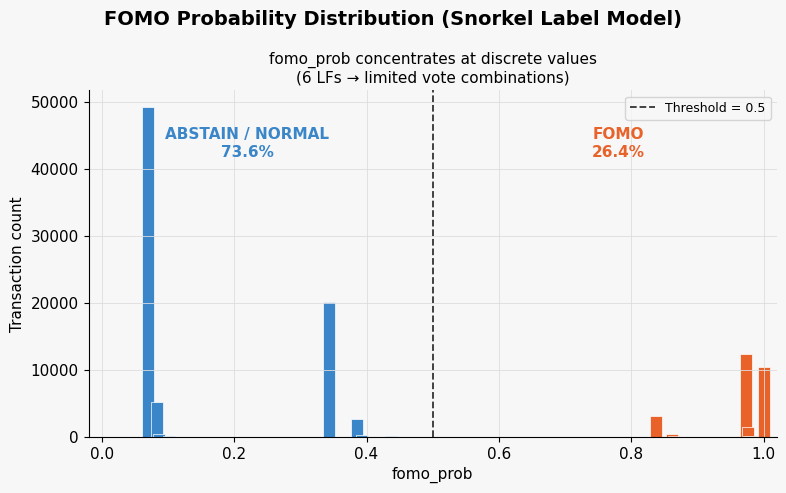

Saved → eda_lf_fig1_fomo_distribution.png


In [17]:
fig1, ax = plt.subplots(figsize=(8, 5))
fig1.suptitle('FOMO Probability Distribution (Snorkel Label Model)',
              fontsize=14, fontweight='bold')

prob_counts = df['fomo_prob'].round(3).value_counts().sort_index()
colors_bar  = [C_FOMO if x > 0.5 else C_NORMAL for x in prob_counts.index]

ax.bar(prob_counts.index, prob_counts.values,
       width=0.018, color=colors_bar, edgecolor='white', linewidth=0.5)

ax.axvline(0.5, linestyle='--', color='#333333', linewidth=1.3, label='Threshold = 0.5')

pct_fomo = (df['fomo_prob'] > 0.5).mean()
ax.text(0.78, prob_counts.max() * 0.85,
        f'FOMO\n{pct_fomo:.1%}', color=C_FOMO,
        fontsize=11, fontweight='bold', ha='center')
ax.text(0.22, prob_counts.max() * 0.85,
        f'ABSTAIN / NORMAL\n{1-pct_fomo:.1%}', color=C_NORMAL,
        fontsize=11, fontweight='bold', ha='center')

ax.set_xlabel('fomo_prob')
ax.set_ylabel('Transaction count')
ax.set_title('fomo_prob concentrates at discrete values\n'
             '(6 LFs → limited vote combinations)', fontsize=11)
ax.set_xlim(-0.02, 1.02)
ax.legend(fontsize=9)

fig1.tight_layout()
fig1.savefig(f'{OUTPUT_DIR}/eda_lf_fig1_fomo_distribution.png',
             dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print('Saved → eda_lf_fig1_fomo_distribution.png')

### 8.5 FIG 2 — LF Signals: RSI Extreme & Value Spike vs fomo_prob
- **Trái:** mean fomo_prob tăng đơn điệu theo RSI bucket → LF_rsi_extreme hoạt động đúng
- **Phải:** value_spike rate tăng theo quartile FOMO → LF_value_spike capture emotional capitulation

/tmp/ipykernel_6937/1077926689.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g['value_spike'] > 1).mean())


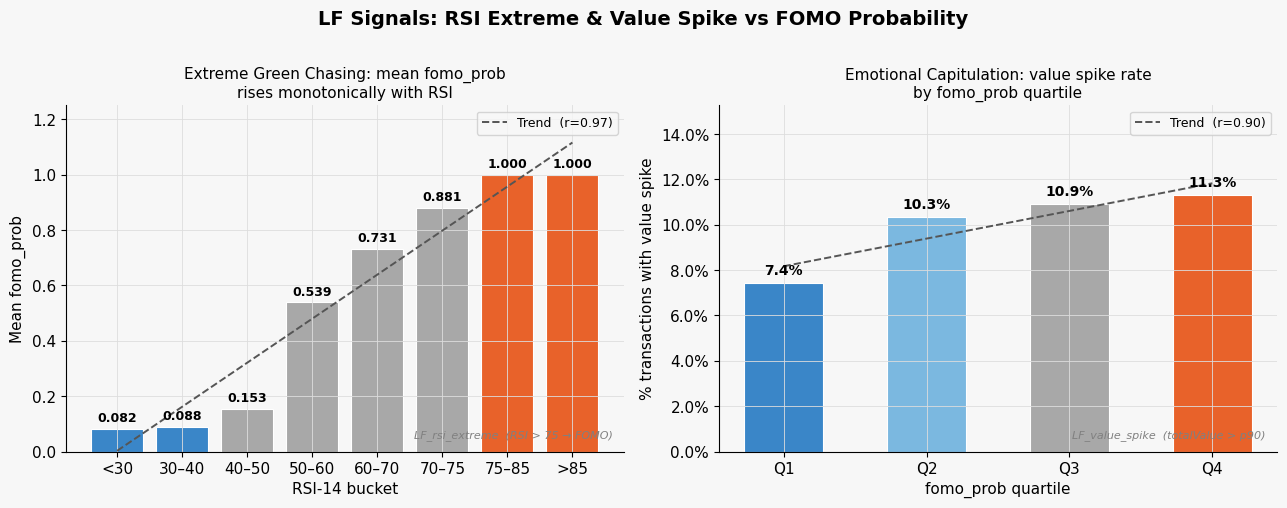

Saved → eda_lf_fig2_lf_signals.png


In [23]:
def mwu_label(a, b):
    """Mann-Whitney U significance label."""
    stat, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    if p < 0.001: return '*** p<.001'
    if p < 0.01:  return '**  p<.01'
    if p < 0.05:  return '*   p<.05'
    return f'ns  p={p:.3f}'

fig2, axes = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle('LF Signals: RSI Extreme & Value Spike vs FOMO Probability',
              fontsize=14, fontweight='bold', y=1.01)

rsi_means  = df.groupby('rsi_bin', observed=True)['fomo_prob'].mean()
spike_rate = (df.groupby('fomo_q', observed=True)
                .apply(lambda g: (g['value_spike'] > 1).mean())
                .reindex(Q_LABELS))

# --- 2a: RSI bucket → mean fomo_prob ---
ax = axes[0]
rsi_colors = [C_FOMO   if any(z in str(l) for z in ['75–85', '>85']) else
              C_NORMAL if any(z in str(l) for z in ['<30', '30–40']) else
              C_MID    for l in rsi_means.index]

bars = ax.bar(rsi_means.index.astype(str), rsi_means.values,
              color=rsi_colors, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.3f', fontsize=9, padding=3, fontweight='bold')

x_num = np.arange(len(rsi_means))
slope, intercept, r, *_ = stats.linregress(x_num, rsi_means.values)
ax.plot(x_num, intercept + slope * x_num,
        linestyle='--', color='#555555', linewidth=1.4, label=f'Trend  (r={r:.2f})')
ax.set_xlabel('RSI-14 bucket')
ax.set_ylabel('Mean fomo_prob')
ax.set_title('Extreme Green Chasing: mean fomo_prob\nrises monotonically with RSI', fontsize=11)
ax.set_ylim(0, rsi_means.max() * 1.25)
ax.legend(fontsize=9)
ax.text(0.98, 0.04, 'LF_rsi_extreme  (RSI > 75 → FOMO)',
        transform=ax.transAxes, fontsize=8, color='grey', ha='right', style='italic')

# --- 2b: Value spike rate by fomo_prob quartile ---
ax = axes[1]
bars = ax.bar(Q_LABELS, spike_rate.values, color=PALETTE_Q,
              edgecolor='white', linewidth=0.8, width=0.55)
ax.bar_label(bars, fmt='{:.1%}', fontsize=10, padding=4, fontweight='bold')

slope, intercept, r, *_ = stats.linregress(np.arange(len(Q_LABELS)), spike_rate.values)
ax.plot(np.arange(len(Q_LABELS)), intercept + slope * np.arange(len(Q_LABELS)),
        linestyle='--', color='#555555', linewidth=1.4, label=f'Trend  (r={r:.2f})')
ax.set_xlabel('fomo_prob quartile')
ax.set_ylabel('% transactions with value spike')
ax.set_title('Emotional Capitulation: value spike rate\nby fomo_prob quartile', fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylim(0, spike_rate.max() * 1.35)
ax.legend(fontsize=9)
ax.text(0.98, 0.04, 'LF_value_spike  (totalValue > p90)',
        transform=ax.transAxes, fontsize=8, color='grey', ha='right', style='italic')

fig2.tight_layout()
fig2.savefig(f'{OUTPUT_DIR}/eda_lf_fig2_lf_signals.png',
             dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print('Saved → eda_lf_fig2_lf_signals.png')

### 8.6 FIG 3 — Rejected Features: risk_level & channel
Cả hai features này không phân biệt được Q1 (Rational) vs Q4 (FOMO) → bị loại khỏi model.

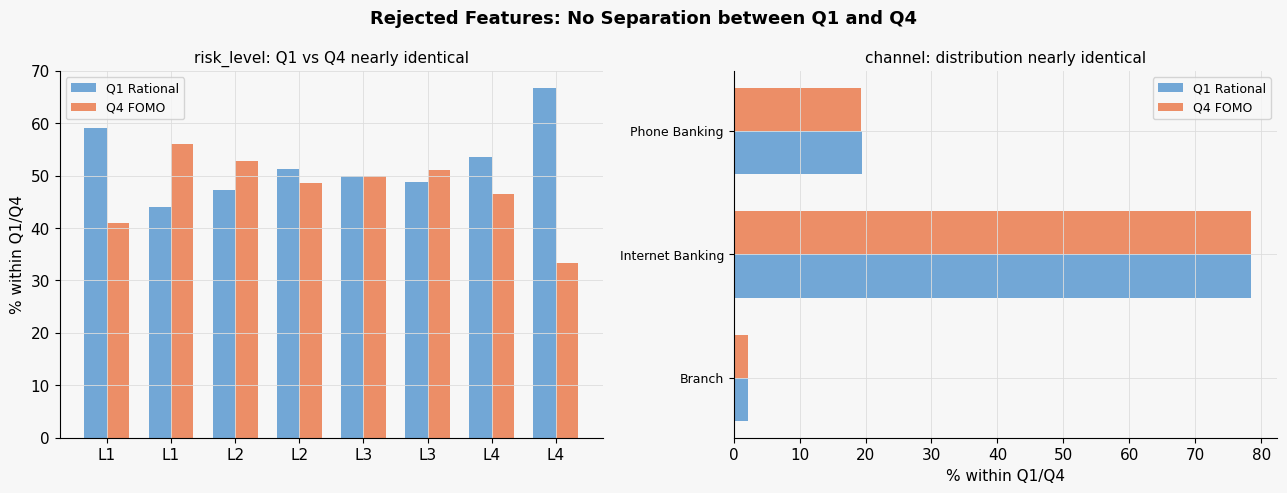

Saved → eda_fig3_rejected_features.png


In [25]:
fig3, axes = plt.subplots(1, 2, figsize=(13, 5))
fig3.suptitle('Rejected Features: No Separation between Q1 and Q4',
              fontsize=13, fontweight='bold')

# --- risk_level ---
ax = axes[0]
risk_pct = (q1q4.groupby(['risk_level', 'fomo_quartile'])
                .size().unstack(fill_value=0)
                .apply(lambda r: r / r.sum() * 100, axis=1))
x = np.arange(len(risk_pct))
w = 0.35
ax.bar(x - w/2, risk_pct.get('Q1', 0), width=w, color=C_NORMAL, alpha=0.7, label='Q1 Rational')
ax.bar(x + w/2, risk_pct.get('Q4', 0), width=w, color=C_FOMO,   alpha=0.7, label='Q4 FOMO')
ax.set_xticks(x)
ax.set_xticklabels([f'L{int(float(l))}' for l in risk_pct.index])
ax.set_title('risk_level: Q1 vs Q4 nearly identical', fontsize=11)
ax.set_ylabel('% within Q1/Q4')
ax.legend(fontsize=9)

# --- channel ---
ax = axes[1]
ch_pct = (q1q4.groupby(['channel', 'fomo_quartile'])
              .size().unstack(fill_value=0)
              .apply(lambda r: r / r.sum() * 100, axis=0))
y = np.arange(len(ch_pct))
ax.barh(y - w/2, ch_pct.get('Q1', 0), height=w, color=C_NORMAL, alpha=0.7, label='Q1 Rational')
ax.barh(y + w/2, ch_pct.get('Q4', 0), height=w, color=C_FOMO,   alpha=0.7, label='Q4 FOMO')
ax.set_yticks(y)
ax.set_yticklabels(ch_pct.index, fontsize=9)
ax.set_title('channel: distribution nearly identical', fontsize=11)
ax.set_xlabel('% within Q1/Q4')
ax.legend(fontsize=9)

fig3.tight_layout()
fig3.savefig(f'{OUTPUT_DIR}/eda_fig3_rejected_features.png',
             dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print('Saved → eda_fig3_rejected_features.png')

### 8.7 FIG 4 — Selected Features: position_size_ratio & macd_hist
Cả hai features này phân biệt rõ Q1 vs Q4 với p<.001 (Mann-Whitney U) → được giữ lại cho XGBoost.

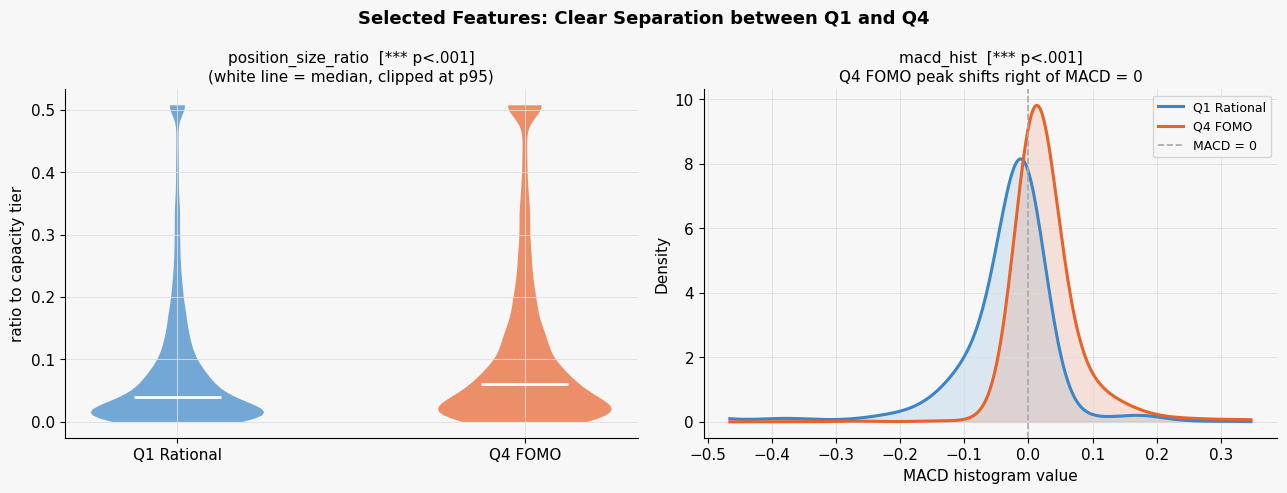

Saved → eda_fig4_selected_features.png


In [26]:
fig4, axes = plt.subplots(1, 2, figsize=(13, 5))
fig4.suptitle('Selected Features: Clear Separation between Q1 and Q4',
              fontsize=13, fontweight='bold')

# --- position_size_ratio: violin + clip outlier ---
ax = axes[0]
cap = q1q4['position_size_ratio'].quantile(0.95)
plot_df = q1q4[['fomo_quartile', 'position_size_ratio']].copy()
plot_df['position_size_ratio'] = plot_df['position_size_ratio'].clip(upper=cap)

parts = ax.violinplot(
    [plot_df[plot_df.fomo_quartile == g]['position_size_ratio'].dropna() for g in ['Q1', 'Q4']],
    positions=[1, 2], showmedians=True, showextrema=False)
for body, color in zip(parts['bodies'], [C_NORMAL, C_FOMO]):
    body.set_facecolor(color); body.set_alpha(0.7)
parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2)

sig = mwu_label(
    *[q1q4[q1q4.fomo_quartile == g]['position_size_ratio'].dropna() for g in ['Q1', 'Q4']]
)
ax.set_xticks([1, 2]); ax.set_xticklabels(['Q1 Rational', 'Q4 FOMO'])
ax.set_title(f'position_size_ratio  [{sig}]\n(white line = median, clipped at p95)', fontsize=11)
ax.set_ylabel('ratio to capacity tier')

# --- macd_hist: KDE overlay ---
ax = axes[1]
kde_x = np.linspace(q1q4['macd_hist'].quantile(0.01),
                    q1q4['macd_hist'].quantile(0.99), 300)
for grp, color, label in [('Q1', C_NORMAL, 'Q1 Rational'), ('Q4', C_FOMO, 'Q4 FOMO')]:
    vals = q1q4[q1q4.fomo_quartile == grp]['macd_hist'].dropna()
    kde  = stats.gaussian_kde(vals, bw_method=0.3)
    ax.plot(kde_x, kde(kde_x), color=color, linewidth=2.2, label=label)
    ax.fill_between(kde_x, kde(kde_x), alpha=0.15, color=color)

ax.axvline(0, linestyle='--', color=C_MID, linewidth=1.2, label='MACD = 0')
sig = mwu_label(
    *[q1q4[q1q4.fomo_quartile == g]['macd_hist'].dropna() for g in ['Q1', 'Q4']]
)
ax.set_title(f'macd_hist  [{sig}]\nQ4 FOMO peak shifts right of MACD = 0', fontsize=11)
ax.set_xlabel('MACD histogram value')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

fig4.tight_layout()
fig4.savefig(f'{OUTPUT_DIR}/eda_fig4_selected_features.png',
             dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print('Saved → eda_fig4_selected_features.png')